# Mathematical Morphological Image Processing

**Paper:** *A Study on Image Processing Using Mathematical Morphological*  
**Authors:** Khairul Anuar Mat Said and Asral Bahari Jambek  
**Conference:** 3rd International Conference on Electronic Design (ICED), 2016

This notebook implements the mathematical morphological workflow described in the paper using manually written image-processing functions.

The paper performs mathematical morphology on a binary image with rectangular structuring elements. The paper does not specify a thresholding procedure for producing the binary input; therefore, manual grayscale conversion and manual Otsu thresholding are used here only as a preprocessing step for the selected source image.


## Section 1: Setup and Input Image

This section imports the required libraries and uploads the input image through Google Colab.


Saving 22.jpg to 22.jpg
Image Name : 22.jpg
Image Size : (600, 597)
Image Mode : RGB


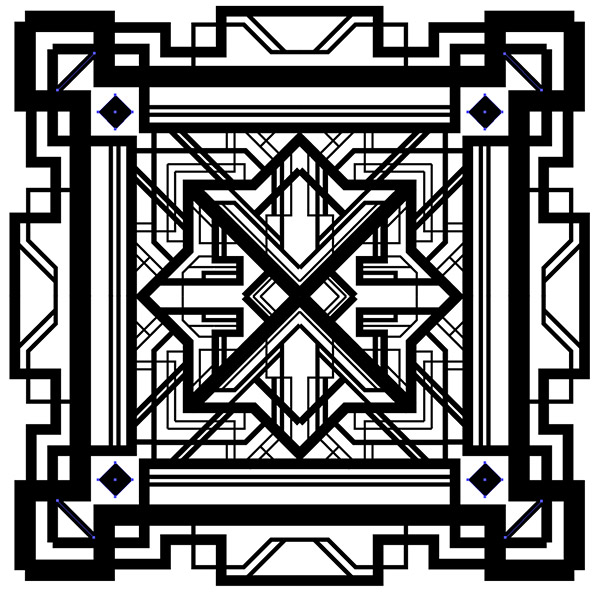

In [1]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = next(iter(uploaded))
image = Image.open(image_path)

print("Image Name :", image_path)
print("Image Size :", image.size)
print("Image Mode :", image.mode)

display(image)


## Section 2: Grayscale and Binary Preprocessing

The selected source image is converted to grayscale manually. Since the paper works with a binary input but does not specify how the source image was binarized, Otsu thresholding is implemented manually and the calculated threshold is directly applied to obtain the binary image.


In [2]:
# Convert the input image to grayscale manually

def rgb_to_grayscale(img):
    if img.mode == "L":
        return img.copy()

    width, height = img.size
    gray = Image.new("L", (width, height))

    for y in range(height):
        for x in range(width):
            pixel = img.getpixel((x, y))

            if len(pixel) >= 3:
                r, g, b = pixel[:3]
            else:
                r = g = b = pixel[0]

            value = int(0.299 * r + 0.587 * g + 0.114 * b)
            gray.putpixel((x, y), value)

    return gray


gray_image = rgb_to_grayscale(image)

print("Grayscale Size :", gray_image.size)
print("Grayscale Mode :", gray_image.mode)


Grayscale Size : (600, 597)
Grayscale Mode : L


In [3]:
# Calculate the Otsu threshold manually

def manual_otsu_threshold(gray_img):
    pixels = list(gray_img.getdata())
    histogram = [0] * 256
    for pixel in pixels:
        histogram[pixel] += 1

    total_pixels = len(pixels)
    total_sum = sum(i * histogram[i] for i in range(256))
    weight_background = 0
    sum_background = 0
    max_variance = -1
    best_threshold = 0

    for threshold in range(256):
        weight_background += histogram[threshold]
        if weight_background == 0:
            continue
        weight_foreground = total_pixels - weight_background
        if weight_foreground == 0:
            break
        sum_background += threshold * histogram[threshold]
        mean_background = sum_background / weight_background
        mean_foreground = (total_sum - sum_background) / weight_foreground
        between_class_variance = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2
        if between_class_variance > max_variance:
            max_variance = between_class_variance
            best_threshold = threshold

    return best_threshold

otsu_threshold = manual_otsu_threshold(gray_image)
print("===== MANUAL OTSU CALCULATION =====")
print("Calculated Otsu Threshold :", otsu_threshold)


===== MANUAL OTSU CALCULATION =====
Calculated Otsu Threshold : 128


===== BINARY CONVERSION =====
Calculated Otsu Threshold : 128
Applied Threshold         : 128
Binary Size               : (600, 597)
Unique Binary Values      : [0, 255]


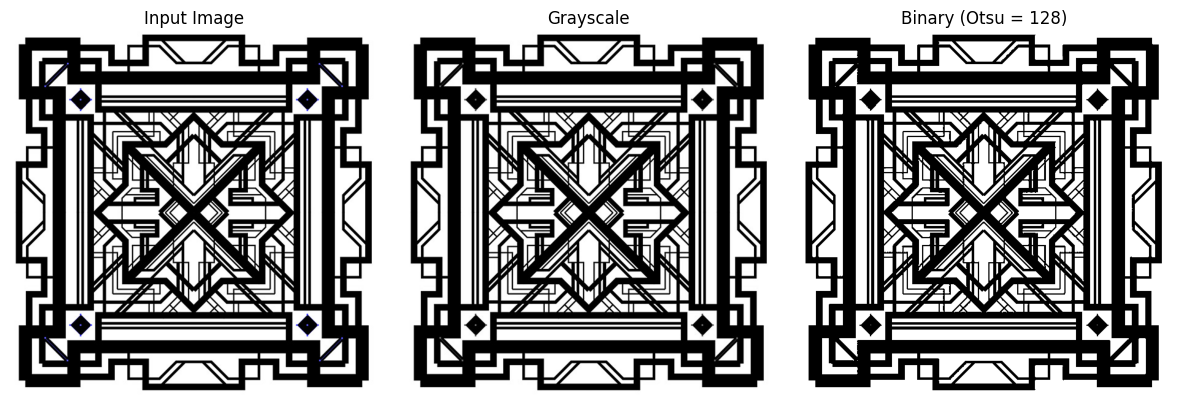

In [4]:
# Create the final binary image using the calculated Otsu threshold

def manual_threshold(gray_img, threshold):
    width, height = gray_img.size
    binary_img = Image.new("L", (width, height), 0)

    for y in range(height):
        for x in range(width):
            pixel = gray_img.getpixel((x, y))

            if pixel >= threshold:
                binary_img.putpixel((x, y), 255)
            else:
                binary_img.putpixel((x, y), 0)

    return binary_img


selected_threshold = otsu_threshold

binary_image = manual_threshold(
    gray_image,
    selected_threshold
)

print("===== BINARY CONVERSION =====")
print("Calculated Otsu Threshold :", otsu_threshold)
print("Applied Threshold         :", selected_threshold)
print("Binary Size               :", binary_image.size)
print("Unique Binary Values      :", sorted(set(binary_image.getdata())))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(binary_image, cmap="gray")
plt.title(f"Binary (Otsu = {selected_threshold})")
plt.axis("off")

plt.tight_layout()
plt.show()


## Section 3: Structuring Element

The paper uses a rectangular structuring element with **8 pixels in width and 4 pixels in height** for the main experiment.

The structuring element is created manually.


In [5]:
# Create a rectangular structuring element manually

def create_rectangular_se(height, width):
    se = []

    for _ in range(height):
        row = []

        for _ in range(width):
            row.append(1)

        se.append(row)

    return se


selected_se = create_rectangular_se(4, 8)

print("Structuring Element: 4 x 8")

for row in selected_se:
    print(row)


Structuring Element: 4 x 8
[1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1]


## Section 4: Morphological Operations

The two basic morphological operations are **Erosion** and **Dilation**. Both are applied to the binary image using the selected 4×8 rectangular structuring element.

- **Erosion:** shrinks foreground structures.
- **Dilation:** enlarges foreground structures.


In [6]:
# Manual erosion and dilation

def manual_erosion(binary_img, se):
    width, height = binary_img.size
    se_height = len(se)
    se_width = len(se[0])

    anchor_y = se_height // 2
    anchor_x = se_width // 2

    eroded = Image.new("L", (width, height), 0)

    for y in range(height):
        for x in range(width):
            fits = True

            for sy in range(se_height):
                for sx in range(se_width):
                    if se[sy][sx] != 1:
                        continue

                    img_x = x + sx - anchor_x
                    img_y = y + sy - anchor_y

                    if (
                        img_x < 0 or img_x >= width
                        or img_y < 0 or img_y >= height
                    ):
                        fits = False
                        break

                    if binary_img.getpixel((img_x, img_y)) != 255:
                        fits = False
                        break

                if not fits:
                    break

            if fits:
                eroded.putpixel((x, y), 255)

    return eroded


def manual_dilation(binary_img, se):
    width, height = binary_img.size
    se_height = len(se)
    se_width = len(se[0])

    anchor_y = se_height // 2
    anchor_x = se_width // 2

    dilated = Image.new("L", (width, height), 0)

    for y in range(height):
        for x in range(width):
            found = False

            for sy in range(se_height):
                for sx in range(se_width):
                    if se[sy][sx] != 1:
                        continue

                    img_x = x + sx - anchor_x
                    img_y = y + sy - anchor_y

                    if (
                        0 <= img_x < width
                        and 0 <= img_y < height
                        and binary_img.getpixel((img_x, img_y)) == 255
                    ):
                        found = True
                        break

                if found:
                    break

            if found:
                dilated.putpixel((x, y), 255)

    return dilated


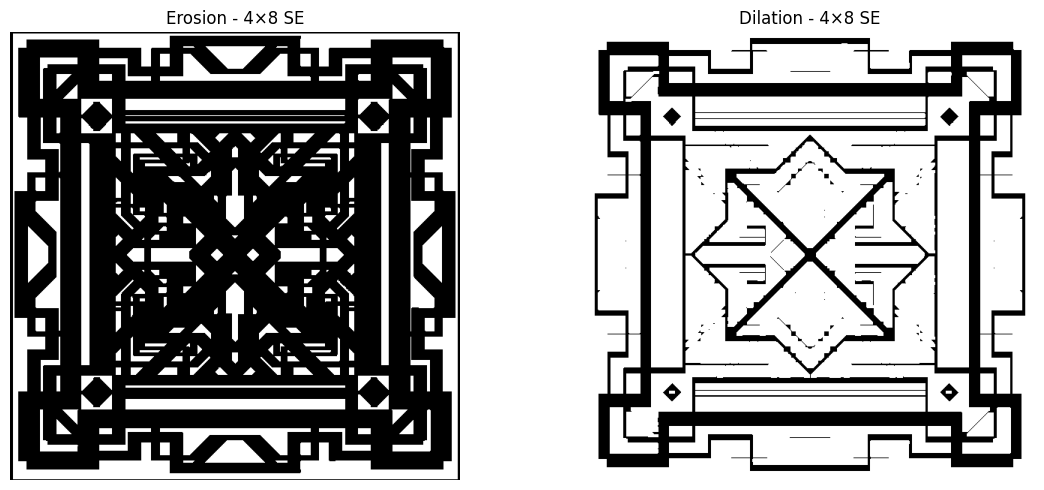

In [7]:
# Apply erosion and dilation

erosion_result = manual_erosion(binary_image, selected_se)
dilation_result = manual_dilation(binary_image, selected_se)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(erosion_result, cmap="gray")
plt.title("Erosion - 4×8 SE")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dilation_result, cmap="gray")
plt.title("Dilation - 4×8 SE")
plt.axis("off")

plt.tight_layout()
plt.show()


## Section 5: Opening and Closing

Opening is obtained by erosion followed by dilation, while closing is obtained by dilation followed by erosion.

The operations continue on the same binary image and use the same 4×8 structuring element.


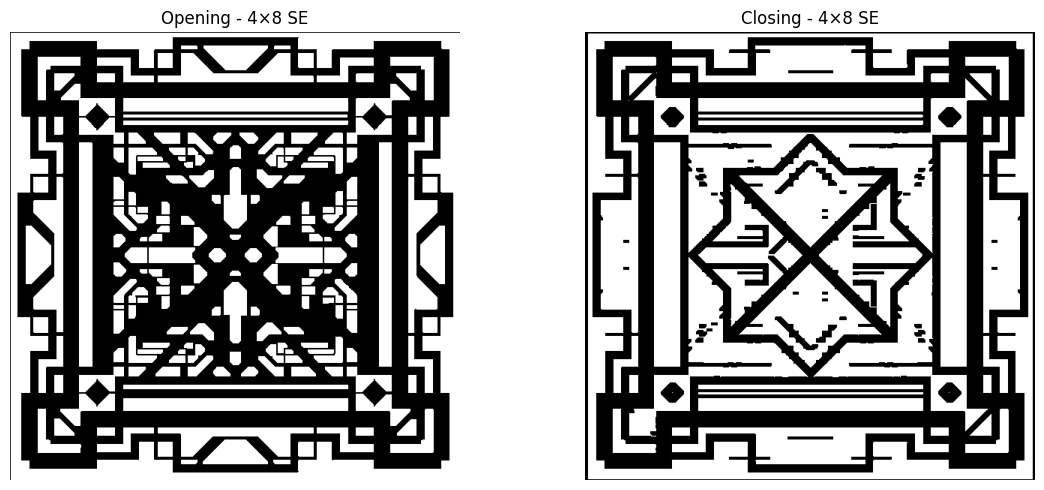

In [8]:
# Apply opening and closing

opening_result = manual_dilation(
    erosion_result,
    selected_se
)

closing_result = manual_erosion(
    dilation_result,
    selected_se
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(opening_result, cmap="gray")
plt.title("Opening - 4×8 SE")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(closing_result, cmap="gray")
plt.title("Closing - 4×8 SE")
plt.axis("off")

plt.tight_layout()
plt.show()


## Section 6: White Top-Hat, Black Top-Hat and Mathematical Morphological Output

This section follows the paper's flow after opening and closing:

- White Top-Hat: `WTH = IM - Opening`
- Black Top-Hat: `BTH = Closing - IM`
- Mathematical Morphological Output: `MM = IM + WTH - BTH`

The paper describes the main processing as being performed on a binary image. The binary erosion, dilation, opening and closing results are therefore retained as the main morphological stages. Because the source image contains anti-aliased intensity values and the paper does not specify its internal numeric representation for the final arithmetic, the final WTH/BTH arithmetic is also evaluated on the original grayscale representation. This preserves the intensity differences visible in the paper's final-output comparison without inventing an additional enhancement parameter.


In [9]:
# Opening and Closing are already available from Section 5

print("Opening and Closing completed.")
print("Opening Size :", opening_result.size)
print("Closing Size :", closing_result.size)


Opening and Closing completed.
Opening Size : (600, 597)
Closing Size : (600, 597)


In [10]:
# White Top-Hat, Black Top-Hat and Mathematical Morphological Output

# The binary opening/closing stages are retained for the main
# morphological workflow. For the final arithmetic, the same
# 4×8 structuring element is applied manually to the grayscale
# source so that the WTH/BTH intensity differences are preserved.

def manual_grayscale_erosion(gray_img, se):
    width, height = gray_img.size
    se_height = len(se)
    se_width = len(se[0])

    anchor_y = se_height // 2
    anchor_x = se_width // 2

    result = Image.new("L", (width, height), 0)

    for y in range(height):
        for x in range(width):
            minimum_value = 255

            for sy in range(se_height):
                for sx in range(se_width):
                    if se[sy][sx] != 1:
                        continue

                    img_x = x + sx - anchor_x
                    img_y = y + sy - anchor_y

                    if 0 <= img_x < width and 0 <= img_y < height:
                        pixel = gray_img.getpixel((img_x, img_y))
                    else:
                        pixel = 0

                    if pixel < minimum_value:
                        minimum_value = pixel

            result.putpixel((x, y), minimum_value)

    return result


def manual_grayscale_dilation(gray_img, se):
    width, height = gray_img.size
    se_height = len(se)
    se_width = len(se[0])

    anchor_y = se_height // 2
    anchor_x = se_width // 2

    result = Image.new("L", (width, height), 0)

    for y in range(height):
        for x in range(width):
            maximum_value = 0

            for sy in range(se_height):
                for sx in range(se_width):
                    if se[sy][sx] != 1:
                        continue

                    img_x = x + sx - anchor_x
                    img_y = y + sy - anchor_y

                    if 0 <= img_x < width and 0 <= img_y < height:
                        pixel = gray_img.getpixel((img_x, img_y))

                        if pixel > maximum_value:
                            maximum_value = pixel

            result.putpixel((x, y), maximum_value)

    return result


# Grayscale opening = erosion followed by dilation
gray_erosion = manual_grayscale_erosion(
    gray_image,
    selected_se
)

gray_opening = manual_grayscale_dilation(
    gray_erosion,
    selected_se
)


# Grayscale closing = dilation followed by erosion
gray_dilation = manual_grayscale_dilation(
    gray_image,
    selected_se
)

gray_closing = manual_grayscale_erosion(
    gray_dilation,
    selected_se
)


# WTH = IM - Opening
# BTH = Closing - IM
# MM  = IM + WTH - BTH

white_tophat = Image.new("L", gray_image.size, 0)
black_tophat = Image.new("L", gray_image.size, 0)
final_result = Image.new("L", gray_image.size, 0)

width, height = gray_image.size

for y in range(height):
    for x in range(width):
        original = gray_image.getpixel((x, y))
        opened = gray_opening.getpixel((x, y))
        closed = gray_closing.getpixel((x, y))

        wth = max(0, original - opened)
        bth = max(0, closed - original)

        final_value = original + wth - bth
        final_value = max(0, min(255, final_value))

        white_tophat.putpixel((x, y), wth)
        black_tophat.putpixel((x, y), bth)
        final_result.putpixel((x, y), final_value)


print("===== MATHEMATICAL MORPHOLOGICAL OUTPUT =====")
print("White Top-Hat : Completed")
print("Black Top-Hat : Completed")
print("Final Output  : Generated")
print("Image Size    :", final_result.size)


===== MATHEMATICAL MORPHOLOGICAL OUTPUT =====
White Top-Hat : Completed
Black Top-Hat : Completed
Final Output  : Generated
Image Size    : (600, 597)


## Section 7: Structuring Element Comparison

The paper compares rectangular structuring elements of **3×8, 4×8, 5×8 and 6×8**. The binary morphology is evaluated for each SE, and the corresponding mathematical morphological output is generated using the same WTH/BTH equations.


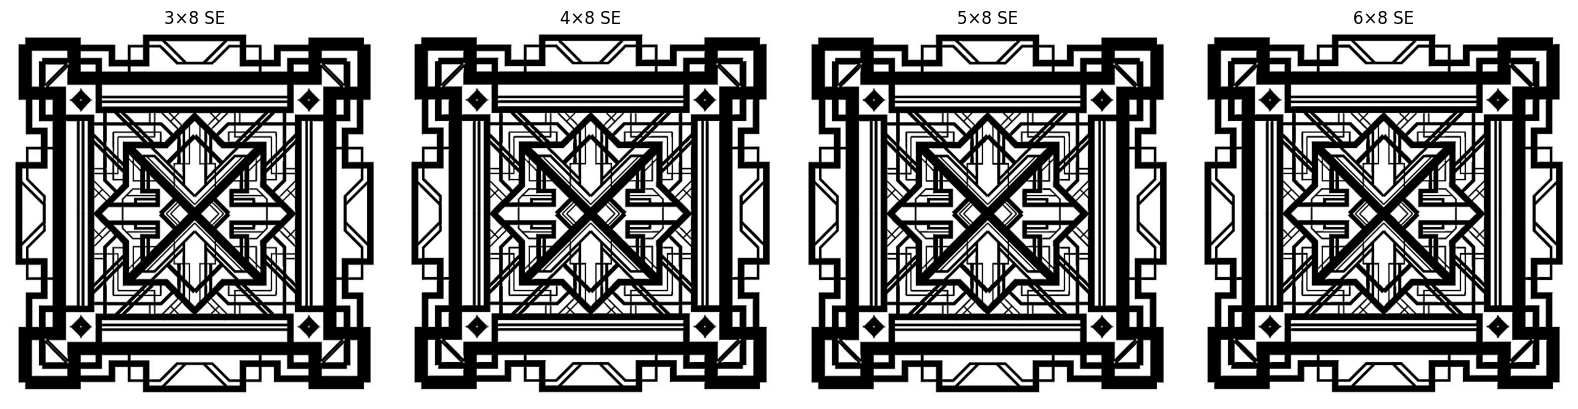

In [11]:
# Compare 3×8, 4×8, 5×8 and 6×8 structuring elements

se_sizes = [(3, 8), (4, 8), (5, 8), (6, 8)]
se_comparison_results = []

for height, width in se_sizes:

    current_se = create_rectangular_se(height, width)

    # Binary morphology
    current_erosion = manual_erosion(
        binary_image,
        current_se
    )

    current_dilation = manual_dilation(
        binary_image,
        current_se
    )

    current_opening = manual_dilation(
        current_erosion,
        current_se
    )

    current_closing = manual_erosion(
        current_dilation,
        current_se
    )

    # Grayscale morphology for WTH/BTH arithmetic
    current_gray_erosion = manual_grayscale_erosion(
        gray_image,
        current_se
    )

    current_gray_opening = manual_grayscale_dilation(
        current_gray_erosion,
        current_se
    )

    current_gray_dilation = manual_grayscale_dilation(
        gray_image,
        current_se
    )

    current_gray_closing = manual_grayscale_erosion(
        current_gray_dilation,
        current_se
    )

    current_final = Image.new(
        "L",
        gray_image.size,
        0
    )

    for y in range(gray_image.height):
        for x in range(gray_image.width):

            original = gray_image.getpixel((x, y))
            opened = current_gray_opening.getpixel((x, y))
            closed = current_gray_closing.getpixel((x, y))

            wth = max(0, original - opened)
            bth = max(0, closed - original)

            value = original + wth - bth
            value = max(0, min(255, value))

            current_final.putpixel(
                (x, y),
                value
            )

    se_comparison_results.append(
        (height, width, current_final)
    )


plt.figure(figsize=(16, 4))

for i, (height, width, result) in enumerate(
    se_comparison_results
):

    plt.subplot(1, 4, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(f"{height}×{width} SE")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Section 8: Final Results and Comparison

The final panel presents the eight main stages in the requested order:

1. Input
2. Erosion
3. Dilation
4. Opening
5. Closing
6. White Top-Hat
7. Black Top-Hat
8. Final Result

The first five stages show the binary morphological operations. The Top-Hat transformations and final mathematical morphological output are shown using the intensity representation used for the final arithmetic.


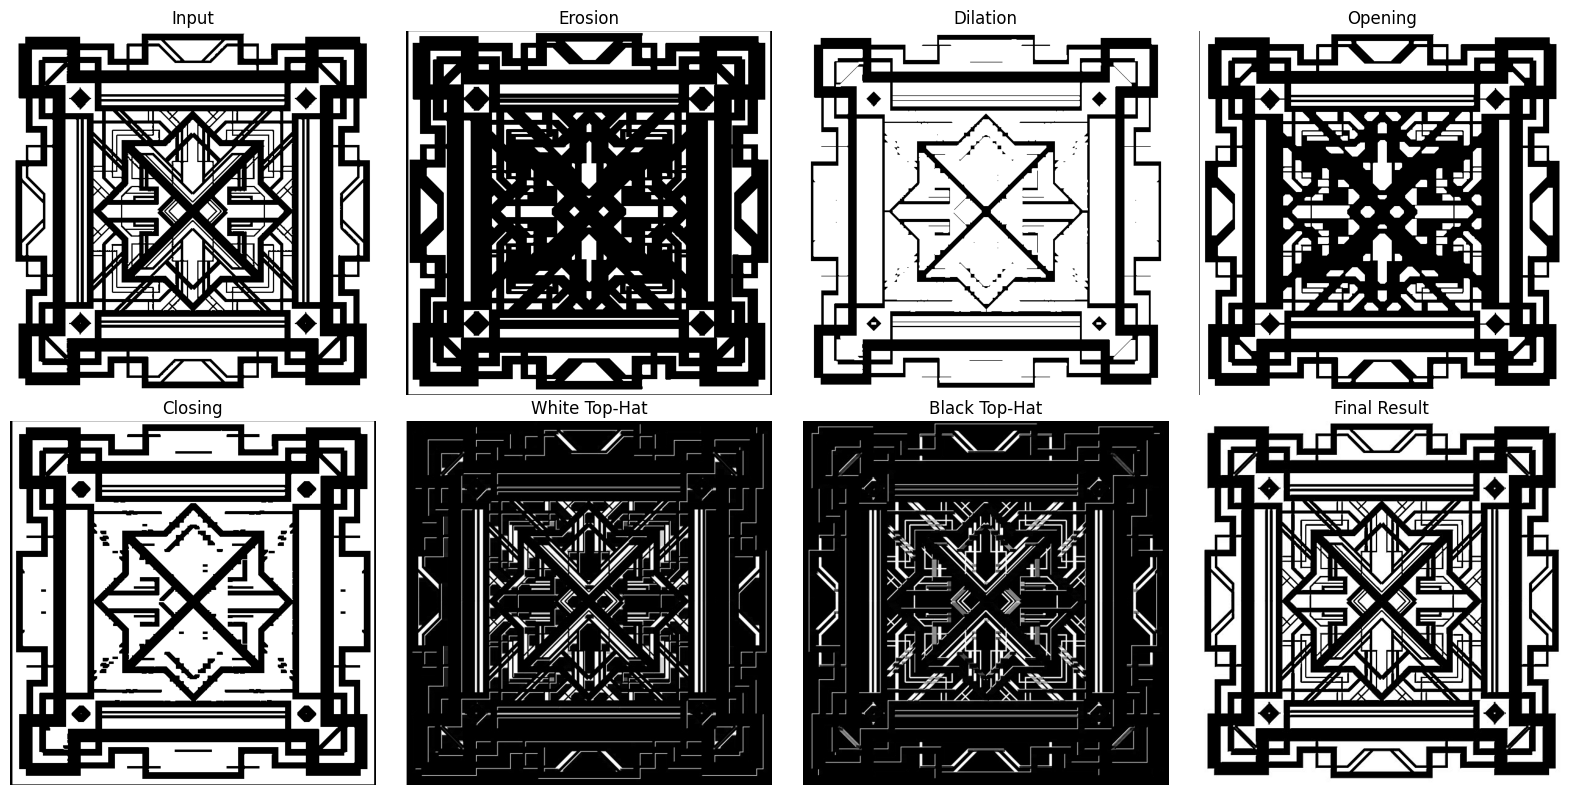

In [12]:
# Display the final eight processing results

final_results = [
    ("Input", binary_image),
    ("Erosion", erosion_result),
    ("Dilation", dilation_result),
    ("Opening", opening_result),
    ("Closing", closing_result),
    ("White Top-Hat", white_tophat),
    ("Black Top-Hat", black_tophat),
    ("Final Result", final_result)
]

plt.figure(figsize=(16, 8))

for i, (title, result) in enumerate(final_results):

    plt.subplot(2, 4, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [13]:
# Numerical comparison between the original grayscale input and final result

width, height = gray_image.size
total_pixels = width * height

sum_input = 0
sum_final = 0
sum_abs_difference = 0
sum_squared_difference = 0
changed_pixels = 0

input_values = []
final_values = []

for y in range(height):
    for x in range(width):

        input_pixel = gray_image.getpixel((x, y))
        final_pixel = final_result.getpixel((x, y))

        input_values.append(input_pixel)
        final_values.append(final_pixel)

        sum_input += input_pixel
        sum_final += final_pixel

        difference = final_pixel - input_pixel

        sum_abs_difference += abs(difference)
        sum_squared_difference += difference ** 2

        if difference != 0:
            changed_pixels += 1


mean_input = sum_input / total_pixels
mean_final = sum_final / total_pixels

std_input = (
    sum((v - mean_input) ** 2 for v in input_values)
    / total_pixels
) ** 0.5

std_final = (
    sum((v - mean_final) ** 2 for v in final_values)
    / total_pixels
) ** 0.5

mae = sum_abs_difference / total_pixels
mse = sum_squared_difference / total_pixels

changed_percentage = (
    changed_pixels / total_pixels
) * 100


print("===== GRAYSCALE INPUT vs FINAL RESULT =====")
print("Image Size              :", width, "×", height)
print("Total Pixels            :", total_pixels)

print("\n--- Intensity Statistics ---")
print("Input Mean Intensity    :", round(mean_input, 4))
print("Final Mean Intensity    :", round(mean_final, 4))
print("Input Standard Deviation:", round(std_input, 4))
print("Final Standard Deviation:", round(std_final, 4))
print("Input Minimum           :", min(input_values))
print("Final Minimum           :", min(final_values))
print("Input Maximum           :", max(input_values))
print("Final Maximum           :", max(final_values))

print("\n--- Pixel Difference ---")
print("Changed Pixels          :", changed_pixels)
print(
    "Changed Pixel Percentage:",
    round(changed_percentage, 4),
    "%"
)

print("\n--- Error Measurements ---")
print("MAE                     :", round(mae, 4))
print("MSE                     :", round(mse, 4))


===== GRAYSCALE INPUT vs FINAL RESULT =====
Image Size              : 600 × 597
Total Pixels            : 358200

--- Intensity Statistics ---
Input Mean Intensity    : 131.4245
Final Mean Intensity    : 130.4993
Input Standard Deviation: 121.8599
Final Standard Deviation: 124.824
Input Minimum           : 0
Final Minimum           : 0
Input Maximum           : 255
Final Maximum           : 255

--- Pixel Difference ---
Changed Pixels          : 90129
Changed Pixel Percentage: 25.1616 %

--- Error Measurements ---
MAE                     : 7.0548
MSE                     : 510.6635


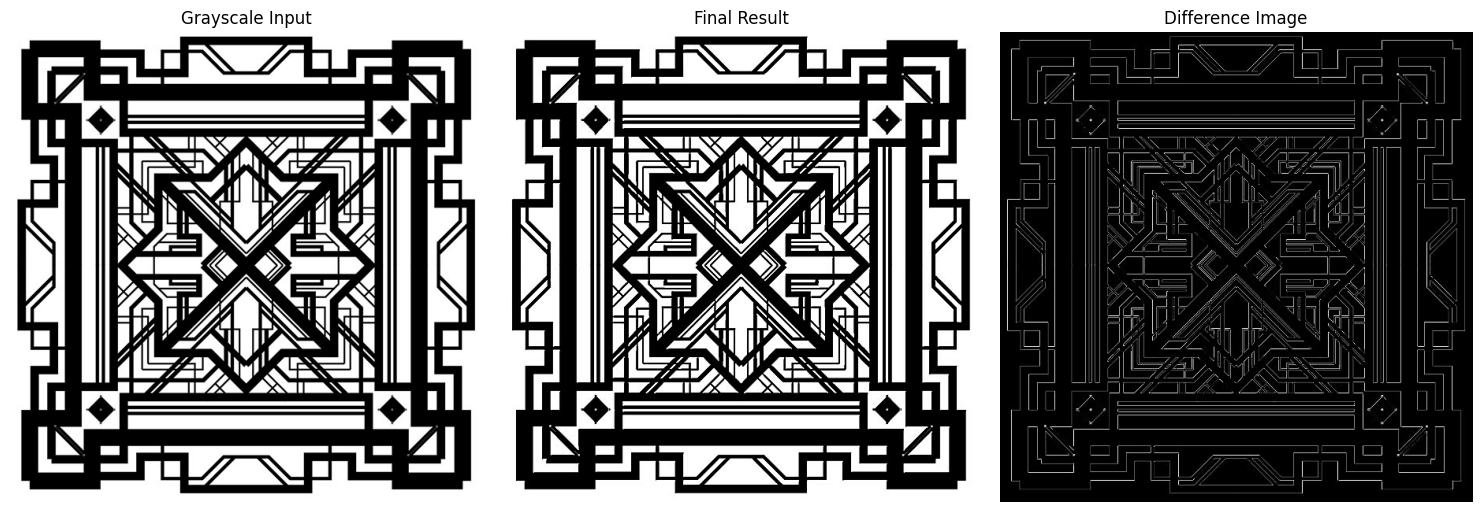

In [14]:
# Create a difference image between grayscale input and final result

difference_image = Image.new(
    "L",
    gray_image.size,
    0
)

for y in range(height):
    for x in range(width):

        input_pixel = gray_image.getpixel((x, y))
        final_pixel = final_result.getpixel((x, y))

        difference = abs(
            final_pixel - input_pixel
        )

        difference_image.putpixel(
            (x, y),
            difference
        )


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(final_result, cmap="gray")
plt.title("Final Result")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(difference_image, cmap="gray")
plt.title("Difference Image")
plt.axis("off")

plt.tight_layout()
plt.show()


## Section 9: Result Analysis

### Morphological Operations

- **Erosion** shrinks foreground structures according to the selected structuring element.
- **Dilation** enlarges foreground structures.
- **Opening** is erosion followed by dilation.
- **Closing** is dilation followed by erosion.
- **White Top-Hat** represents the difference between the image and its opening.
- **Black Top-Hat** represents the difference between the closing and the image.
- The selected 4×8 rectangular structuring element is used for the main experiment.

### Mathematical Morphological Output

The final output follows the paper's equations:

- `WTH = IM - Opening`
- `BTH = Closing - IM`
- `MM = IM + WTH - BTH`

The paper reports that the final output makes the gaps between stacked rectangular boxes clearer and sharper, and that the structuring element affects the result.

### Numerical Comparison

The original grayscale representation and the final output are compared using:

- Mean intensity
- Standard deviation
- Minimum and maximum intensity
- Changed pixel count
- Changed pixel percentage
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)

### Difference Image

The difference image shows the absolute intensity change between the original grayscale representation and the final mathematical morphological output.

### Structuring Element Comparison

The 3×8, 4×8, 5×8 and 6×8 rectangular structuring elements are compared to observe how SE size affects the output.


## Section 10: Conclusion and Reference

The notebook implements the mathematical morphological workflow presented in the paper using a manually created 4×8 rectangular structuring element. Erosion, dilation, opening, closing, White Top-Hat and Black Top-Hat operations are implemented without using built-in morphology functions.

The paper's mathematical morphological output is generated from:

`MM = IM + WTH - BTH`

The 3×8, 4×8, 5×8 and 6×8 structuring elements are also compared. The 4×8 rectangular SE is the main SE used in the experiment, matching the paper's methodology.

### Reference

Khairul Anuar Mat Said and Asral Bahari Jambek, “A Study on Image Processing Using Mathematical Morphological,” *2016 3rd International Conference on Electronic Design (ICED)*, Phuket, Thailand, 2016.
